# Graph and Diffusion Analysis

This notebook studies the propagation graphs behind the fake-news datasets. It inspects structural statistics, degree distributions, node centrality, community structure, and visually interprets diffusion patterns.

In [4]:
import os
import sys
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sys.path.insert(0, os.path.abspath('..'))

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'font.size': 11,
    'savefig.dpi': 150,
    'figure.dpi': 150,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def load_graph_data(dataset: str, raw_dir: str = '../data/raw') -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray]:
    dataset_dir = Path(raw_dir) / dataset
    edge_path = dataset_dir / 'A.txt'
    graph_labels_path = dataset_dir / 'graph_labels.npy'
    node_graph_id_path = dataset_dir / 'node_graph_id.npy'

    if not edge_path.exists():
        raise FileNotFoundError(f'Edge list not found: {edge_path}')

    if edge_path.stat().st_size > 0:
        edges = pd.read_csv(edge_path, header=None, names=['src', 'dst'], dtype={'src': 'int32', 'dst': 'int32'})
    else:
        edges = pd.DataFrame(columns=['src', 'dst'])

    graph_labels = np.load(graph_labels_path)
    node_graph_id = np.load(node_graph_id_path)
    return edges, graph_labels, node_graph_id, np.arange(len(graph_labels))


def build_graph(edges: pd.DataFrame, directed: bool = True) -> nx.Graph:
    graph = nx.DiGraph() if directed else nx.Graph()
    graph.add_edges_from(edges[['src', 'dst']].itertuples(index=False, name=None))
    return graph


def graph_statistics(graph: nx.Graph) -> dict:
    undirected = graph.to_undirected()
    n_nodes = graph.number_of_nodes()
    n_edges = graph.number_of_edges()
    degree_values = np.array([degree for _, degree in undirected.degree()]) if n_nodes else np.array([])
    return {
        'nodes': n_nodes,
        'edges': n_edges,
        'density': nx.density(undirected) if n_nodes > 1 else 0.0,
        'average_degree': float(degree_values.mean()) if degree_values.size else 0.0,
        'max_degree': int(degree_values.max()) if degree_values.size else 0,
        'connected_components': nx.number_connected_components(undirected) if n_nodes else 0,
        'largest_component_size': len(max(nx.connected_components(undirected), key=len)) if n_nodes else 0,
    }


def centrality_table(graph: nx.Graph) -> pd.DataFrame:
    undirected = graph.to_undirected()
    degree_centrality = nx.degree_centrality(undirected)
    if undirected.number_of_nodes() > 1500:
        sample_k = min(100, undirected.number_of_nodes() - 1)
        betweenness_centrality = nx.betweenness_centrality(undirected, k=sample_k, seed=RANDOM_STATE)
    else:
        betweenness_centrality = nx.betweenness_centrality(undirected)
    closeness_centrality = nx.closeness_centrality(undirected)
    try:
        eigenvector_centrality = nx.eigenvector_centrality(undirected, max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        eigenvector_centrality = {node: np.nan for node in undirected.nodes()}

    table = pd.DataFrame({
        'node': list(undirected.nodes()),
        'degree_centrality': pd.Series(degree_centrality),
        'betweenness_centrality': pd.Series(betweenness_centrality),
        'closeness_centrality': pd.Series(closeness_centrality),
        'eigenvector_centrality': pd.Series(eigenvector_centrality),
        'degree': pd.Series(dict(undirected.degree())),
    }).reset_index(drop=True)
    return table.sort_values('degree_centrality', ascending=False)


def community_table(graph: nx.Graph) -> tuple[list[set[int]], pd.DataFrame]:
    undirected = graph.to_undirected()
    if undirected.number_of_nodes() == 0:
        return [], pd.DataFrame(columns=['community_id', 'size'])
    largest_nodes = max(nx.connected_components(undirected), key=len)
    subgraph = undirected.subgraph(largest_nodes).copy()
    communities = list(nx.algorithms.community.greedy_modularity_communities(subgraph))
    community_df = pd.DataFrame({
        'community_id': list(range(len(communities))),
        'size': [len(c) for c in communities],
    }).sort_values('size', ascending=False)
    return communities, community_df


def plot_degree_distribution(graph: nx.Graph, title: str) -> None:
    degrees = [degree for _, degree in graph.to_undirected().degree()]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(degrees, bins=50, kde=True, ax=ax, color='#2E86AB')
    ax.set_title(title)
    ax.set_xlabel('Node degree')
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()


def plot_graph_structure(graph: nx.Graph, title: str, communities: list[set[int]] | None = None, top_n: int = 120) -> None:
    undirected = graph.to_undirected()
    degree_order = sorted(undirected.degree, key=lambda item: item[1], reverse=True)
    selected_nodes = [node for node, _ in degree_order[: min(top_n, len(degree_order))]]
    subgraph = undirected.subgraph(selected_nodes).copy()
    pos = nx.spring_layout(subgraph, seed=RANDOM_STATE, k=0.4)
    fig, ax = plt.subplots(figsize=(11, 8))

    if communities:
        community_map = {}
        for community_id, community_nodes in enumerate(communities):
            for node in community_nodes:
                community_map[node] = community_id
        colors = [community_map.get(node, -1) for node in subgraph.nodes()]
        nodes = nx.draw_networkx_nodes(subgraph, pos, node_color=colors, cmap='tab20', node_size=80, alpha=0.9, ax=ax)
        nodes.set_edgecolor('white')
    else:
        nx.draw_networkx_nodes(subgraph, pos, node_color='#2E86AB', node_size=80, alpha=0.9, ax=ax)

    nx.draw_networkx_edges(subgraph, pos, alpha=0.25, width=0.8, ax=ax)
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## Graph Loading and Basic Statistics

The diffusion graphs are constructed from the edge list in `A.txt`. We measure graph scale, density, average degree, and connected-component structure for each dataset.

Loading POLITIFACT graph data...
POLITIFACT graph summary
Nodes: 41,054
Edges: 40,740


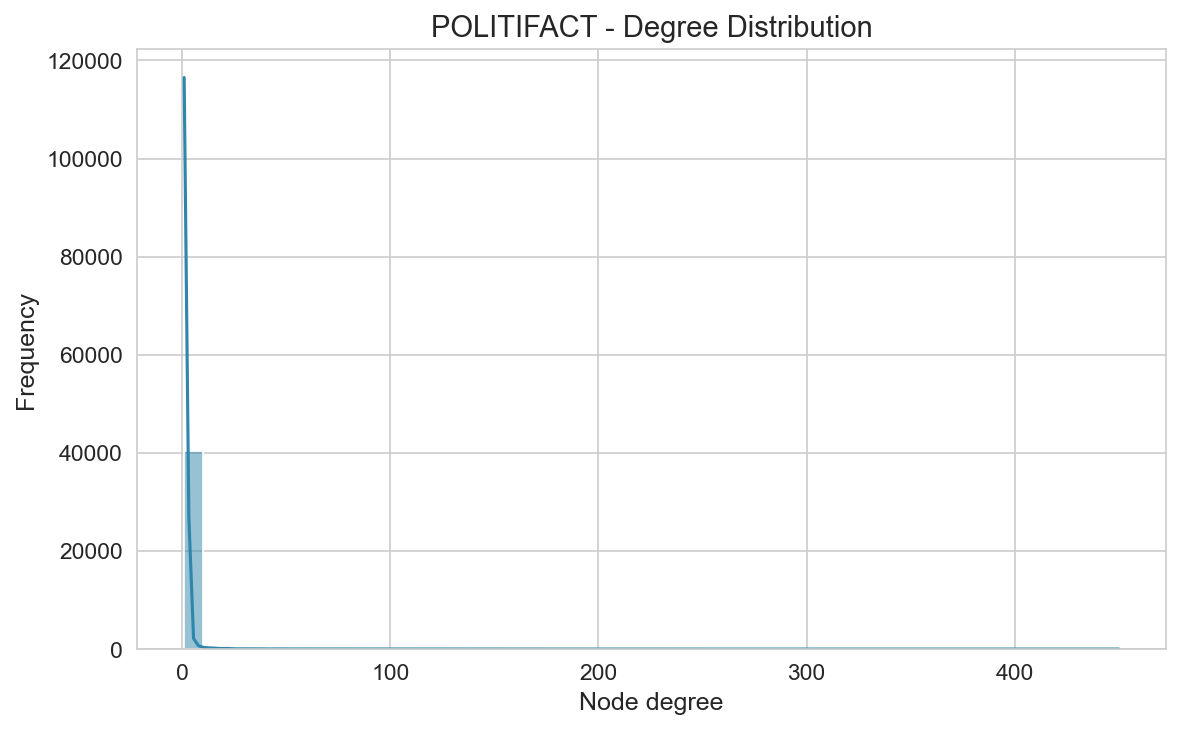

Cleaned up POLITIFACT from memory

Loading GOSSIPCOP graph data...
GOSSIPCOP graph summary
Nodes: 314,262
Edges: 308,798


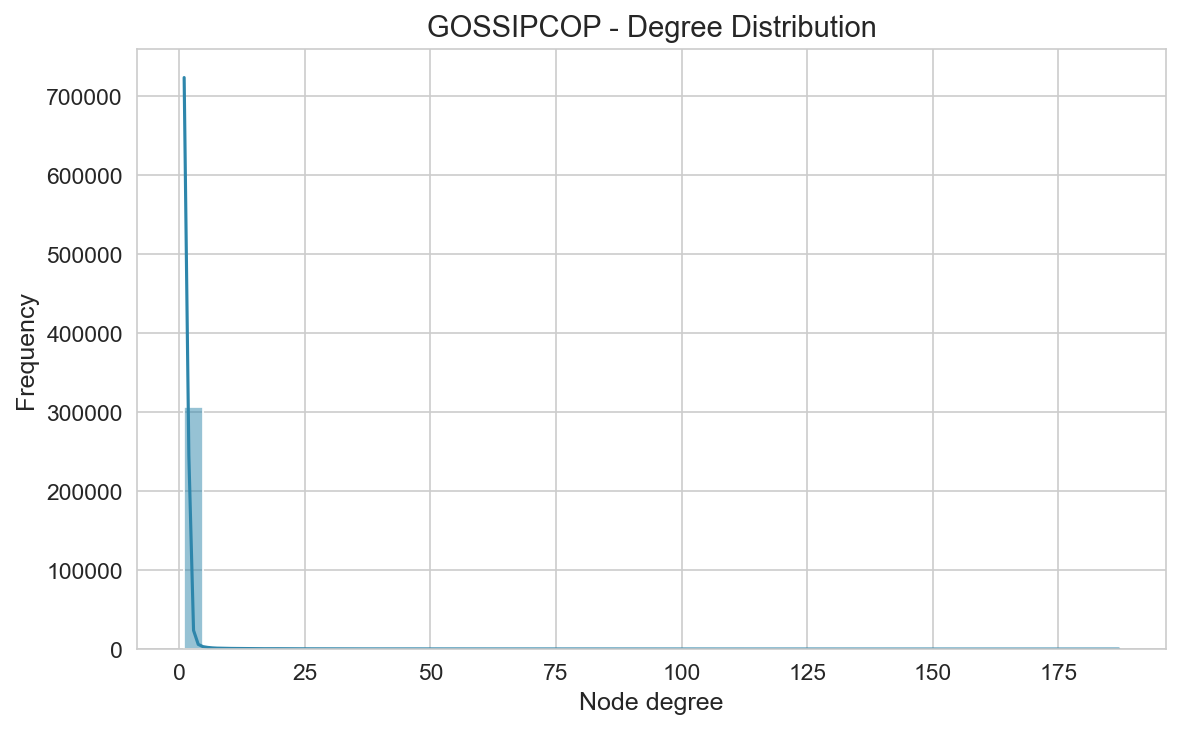

Cleaned up GOSSIPCOP from memory



,nodes,edges,density,average_degree,max_degree,connected_components,largest_component_size
dataset,,,,,,,
politifact,41054,40740,0.0,1.9847,450,314,497
gossipcop,314262,308798,0.0,1.9652,187,5464,199


In [5]:
datasets = ['politifact', 'gossipcop']
summary_rows = []

# Process each dataset separately to manage memory
for dataset in datasets:
    print(f'Loading {dataset.upper()} graph data...')
    edges, graph_labels, node_graph_id, graph_index = load_graph_data(dataset)
    graph = build_graph(edges, directed=True)

    stats = graph_statistics(graph)
    stats['dataset'] = dataset
    summary_rows.append(stats)

    print(f'{dataset.upper()} graph summary')
    print(f'Nodes: {graph.number_of_nodes():,}')
    print(f'Edges: {graph.number_of_edges():,}')
    
    plot_degree_distribution(graph, f'{dataset.upper()} - Degree Distribution')
    
    # Clean up
    del edges, graph_labels, node_graph_id, graph_index, graph
    gc.collect()
    print(f'Cleaned up {dataset.upper()} from memory\n')

summary_df = pd.DataFrame(summary_rows).set_index('dataset')
display(summary_df.round(4))

## Centrality, Communities, and Visualization

Centrality identifies hub and bridge nodes that may amplify or steer information flow. Community structure helps interpret whether diffusion is organized in tight local neighborhoods or spread across loosely connected subgraphs.


Processing POLITIFACT - Centrality & Community Analysis
Computing centrality measures for POLITIFACT...
Computing community structure for POLITIFACT...

POLITIFACT - Top 10 Central Nodes


,node,degree,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality
0,0,450,0.01096,0.00012,0.01070,0.70615
9510,9510,414,0.01008,0.00000,0.01007,0.02819
13452,13452,321,0.00782,0.00009,0.00790,0.00000
4921,4921,300,0.00731,0.00019,0.00698,0.00000
2597,2597,285,0.00694,0.00023,0.00799,0.00000
24922,24922,282,0.00687,0.00000,0.00742,0.00000
39776,39776,280,0.00682,0.00012,0.00820,0.00000
37036,37036,272,0.00663,0.00007,0.00670,0.00000
26352,26352,268,0.00653,0.00000,0.00659,0.00000
35572,35572,266,0.00648,0.00019,0.00715,0.00000



POLITIFACT - Community Structure


,dataset,community_id,size
0,politifact,0,423
2,politifact,2,5
3,politifact,3,5
4,politifact,4,5
5,politifact,5,5
1,politifact,1,5
6,politifact,6,4
7,politifact,7,3
23,politifact,23,2
20,politifact,20,2


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_3940\1259535992.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=community_df, x='community_id', y='size', palette='Blues_r', ax=ax)


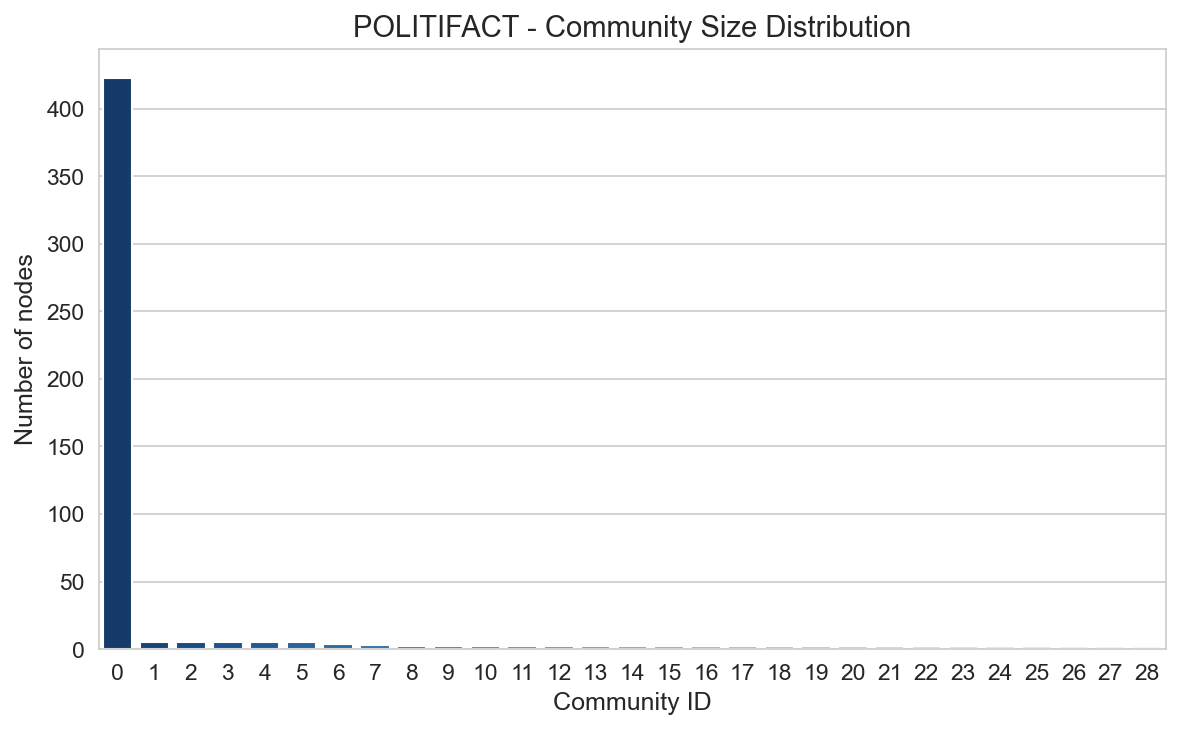

Visualizing largest information cascade for POLITIFACT...


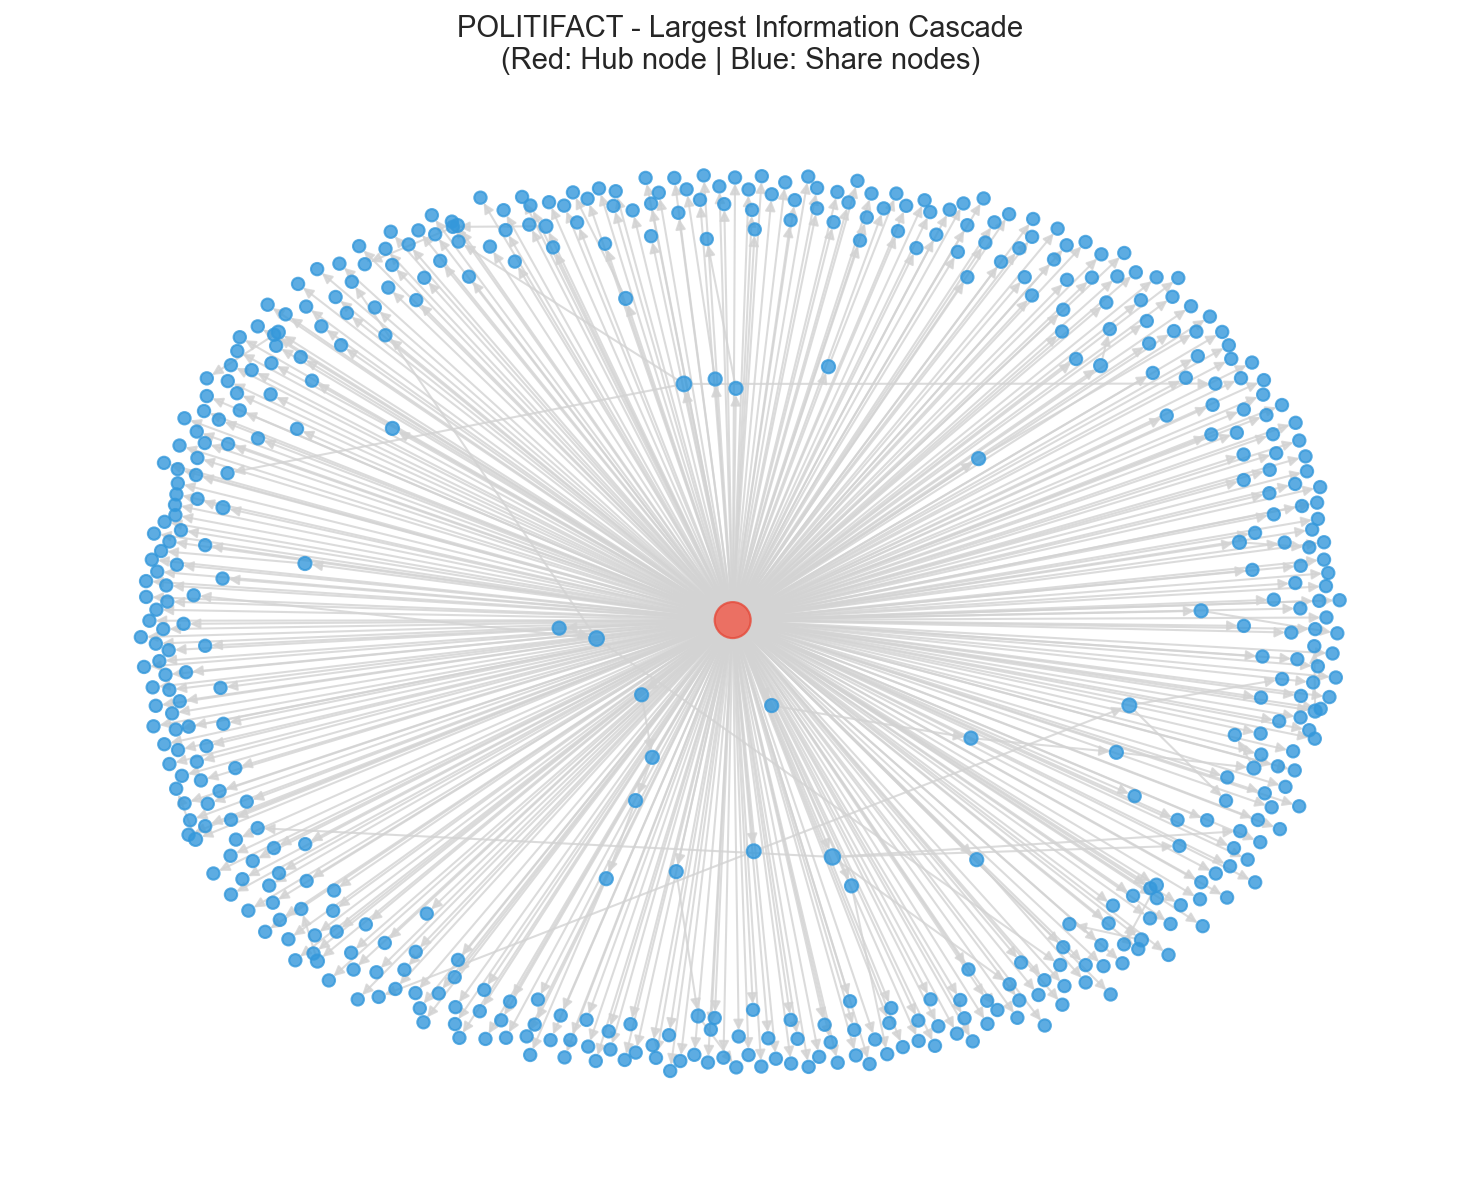

Cleaned up POLITIFACT from memory

Processing GOSSIPCOP - Centrality & Community Analysis
Computing centrality measures for GOSSIPCOP...
Computing community structure for GOSSIPCOP...

GOSSIPCOP - Top 10 Central Nodes


,node,degree,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality
147634,147634,187,0.00060,0.00000,0.00060,0.60746
94576,94576,181,0.00058,0.00000,0.00058,0.18331
33154,33154,181,0.00058,0.00000,0.00058,0.18698
153531,153531,180,0.00057,0.00001,0.00057,0.14953
182316,182316,179,0.00057,0.00000,0.00057,0.12480
69061,69061,179,0.00057,0.00000,0.00057,0.12279
126781,126781,176,0.00056,0.00000,0.00056,0.06539
20450,20450,174,0.00055,0.00000,0.00056,0.04419
311649,311649,173,0.00055,0.00000,0.00055,0.03500
158644,158644,173,0.00055,0.00000,0.00055,0.03598



GOSSIPCOP - Community Structure


,dataset,community_id,size
0,gossipcop,0,95
1,gossipcop,1,58
2,gossipcop,2,12
3,gossipcop,3,10
4,gossipcop,4,3
5,gossipcop,5,3
6,gossipcop,6,3
7,gossipcop,7,3
8,gossipcop,8,2
9,gossipcop,9,2


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_3940\1259535992.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=community_df, x='community_id', y='size', palette='Blues_r', ax=ax)


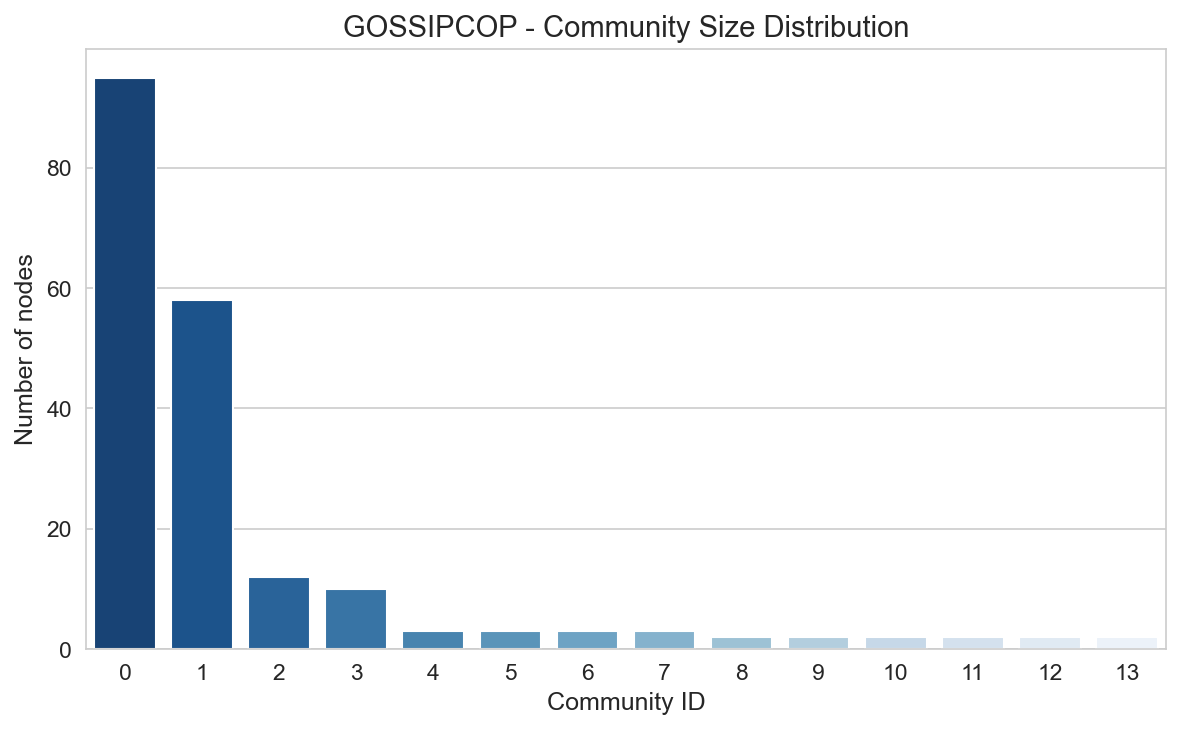

Visualizing largest information cascade for GOSSIPCOP...


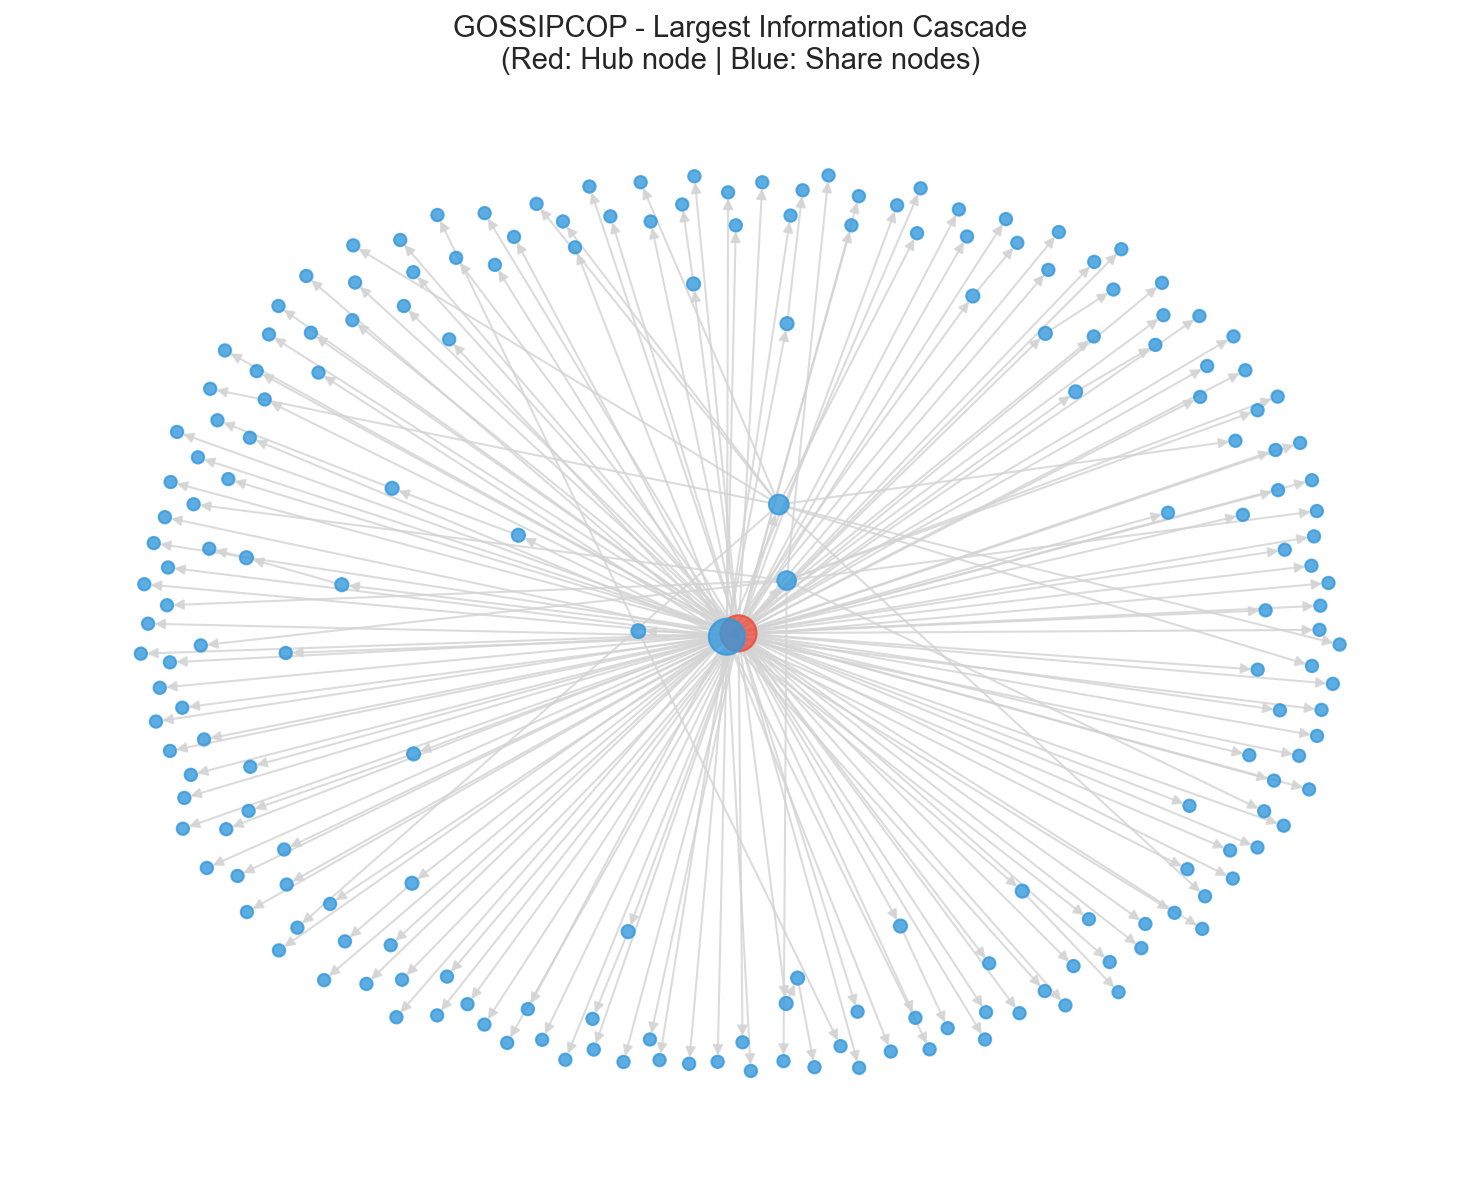

Cleaned up GOSSIPCOP from memory

COMBINED RESULTS - All Datasets

Overall Centrality Summary (Top nodes from each dataset)


,dataset,node,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality,degree
0,politifact,0,0.01096,0.00012,0.01070,0.70615,450
1,politifact,9510,0.01008,0.00000,0.01007,0.02819,414
2,politifact,13452,0.00782,0.00009,0.00790,0.00000,321
3,politifact,4921,0.00731,0.00019,0.00698,0.00000,300
4,politifact,2597,0.00694,0.00023,0.00799,0.00000,285
5,politifact,24922,0.00687,0.00000,0.00742,0.00000,282
6,politifact,39776,0.00682,0.00012,0.00820,0.00000,280
7,politifact,37036,0.00663,0.00007,0.00670,0.00000,272
8,politifact,26352,0.00653,0.00000,0.00659,0.00000,268
9,politifact,35572,0.00648,0.00019,0.00715,0.00000,266



Overall Community Summary (All datasets)


,dataset,community_id,size
0,politifact,0,423
1,politifact,2,5
2,politifact,3,5
3,politifact,4,5
4,politifact,5,5
5,politifact,1,5
6,politifact,6,4
7,politifact,7,3
8,politifact,23,2
9,politifact,20,2


In [6]:
all_centrality_rows = []
all_community_rows = []

# Process each dataset separately
for dataset in datasets:
    print(f'\n{"="*60}')
    print(f'Processing {dataset.upper()} - Centrality & Community Analysis')
    print(f'{"="*60}')
    
    # Load graph
    edges, graph_labels, node_graph_id, graph_index = load_graph_data(dataset)
    graph = build_graph(edges, directed=True)
    
    # Calculate centralities
    print(f'Computing centrality measures for {dataset.upper()}...')
    centralities = centrality_table(graph)
    centralities.insert(0, 'dataset', dataset)
    all_centrality_rows.append(centralities.head(10))
    
    # Calculate communities
    print(f'Computing community structure for {dataset.upper()}...')
    communities, community_df = community_table(graph)
    community_df.insert(0, 'dataset', dataset)
    all_community_rows.append(community_df)
    
    # Display centrality results
    top_nodes = centralities.head(10)[['node', 'degree', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'eigenvector_centrality']]
    print(f'\n{dataset.upper()} - Top 10 Central Nodes')
    display(top_nodes.round(5))
    
    # Display community results
    print(f'\n{dataset.upper()} - Community Structure')
    display(community_df.round(4))

    # Visualize community size distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=community_df, x='community_id', y='size', palette='Blues_r', ax=ax)
    ax.set_title(f'{dataset.upper()} - Community Size Distribution')
    ax.set_xlabel('Community ID')
    ax.set_ylabel('Number of nodes')
    plt.tight_layout()
    plt.show()

    # Visualize largest cascade structure in the network
    print(f'Visualizing largest information cascade for {dataset.upper()}...')
    undirected_G = graph.to_undirected()
    largest_cc = max(nx.connected_components(undirected_G), key=len)
    biggest_cascade = graph.subgraph(largest_cc)

    fig, ax = plt.subplots(figsize=(10, 8))
    # Spring layout uses physics-inspired forces to spread nodes apart
    pos = nx.spring_layout(biggest_cascade, k=0.15, iterations=50, seed=RANDOM_STATE) 
    
    # Highlight the highest-degree node (information source/hub) in red
    # Other nodes (shares/reactions) are shown in blue
    degrees = dict(biggest_cascade.degree())
    root_node = max(degrees, key=degrees.get)
    
    node_colors = ['#e74c3c' if node == root_node else '#3498db' for node in biggest_cascade.nodes()]
    node_sizes = [min(degrees[n] * 5 + 30, 300) for n in biggest_cascade.nodes()]

    nx.draw(biggest_cascade, pos, 
            node_size=node_sizes, 
            node_color=node_colors, 
            edge_color='lightgray', 
            alpha=0.8, 
            with_labels=False,
            ax=ax)
    
    ax.set_title(f'{dataset.upper()} - Largest Information Cascade\n(Red: Hub node | Blue: Share nodes)')
    plt.tight_layout()
    plt.show()
    
    # Clean up before next iteration
    del edges, graph_labels, node_graph_id, graph_index, graph, undirected_G, largest_cc, biggest_cascade
    del centralities, communities, community_df, top_nodes, degrees, root_node, node_colors, node_sizes, pos, ax, fig
    gc.collect()
    print(f'Cleaned up {dataset.upper()} from memory')

# Combine results from all datasets
centrality_df = pd.concat(all_centrality_rows, ignore_index=True)
community_df = pd.concat(all_community_rows, ignore_index=True)

print('\n' + '='*60)
print('COMBINED RESULTS - All Datasets')
print('='*60)

print('\nOverall Centrality Summary (Top nodes from each dataset)')
display(centrality_df.round(5))

print('\nOverall Community Summary (All datasets)')
display(community_df.round(4))

## Summary and Key Insights

### Network Structural Properties

1. **Scale and Density**
   - Network density indicates how interconnected the graph is
   - Higher density suggests information spreads more easily across the network
   - Average degree shows the typical number of connections per node

2. **Degree Distribution**
   - Power-law distributions (long tail) indicate scale-free networks with hub nodes
   - Hub nodes are critical information sources and potential amplifiers
   - Networks with few hubs are more centralized and vulnerable to targeted disruption

3. **Connected Components**
   - Multiple components indicate isolated subgraphs with limited cross-talk
   - The largest component typically contains the main information cascade
   - Small isolated components may represent independent discussions

### Centrality Analysis

**Degree Centrality** - Direct connections; high-degree nodes are local hubs  
**Betweenness Centrality** - Bridge nodes connecting separate communities; important for information flow  
**Closeness Centrality** - Proximity to all other nodes; high values indicate central positioning  
**Eigenvector Centrality** - Connected to other important nodes; indicates influential users  

Nodes high in betweenness often connect different communities and can amplify misinformation across social boundaries.

### Community Structure

Communities represent subgroups of tightly-connected users. In fake-news contexts:
- **Tight communities** → Echo chambers that reinforce shared beliefs
- **Hub-and-spoke structure** → Information flows through central sources
- **Balanced sizes** → More diffuse influence; unequal sizes → concentrated power

### Implications for Fake-News Detection

1. **Graph-based models** benefit from network structure because real and fake news may have different cascade patterns
2. **Hub nodes** in fake-news cascades may use different language or tactics than peripheral users
3. **Community detection** helps identify echo chambers where misinformation thrives
4. **Centrality measures** capture structural roles that text-only models cannot see
